In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy as sp
from scipy import io
import scipy.ndimage as ndimage
import skimage
from skimage import measure
import skimage.morphology as morphology


In [2]:
data = sp.io.loadmat('data/2013_DFC_contest.mat')

In [3]:
lidar = data['lidar']
hsi = data['hyper']

/var/folders/_5/q5djzf3j101ch1t5bw1hjjnw000103/T/ipykernel_32596/1448933845.py:13: RuntimeWarning: invalid value encountered in divide
  ratio = np.divide(band1, band2)


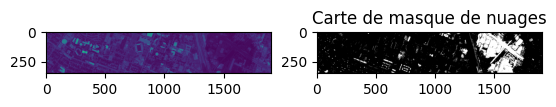

In [4]:
# Sélectionner les longueurs d'onde pour le calcul du ratio spectral
wl1 = 440  # Longueur d'onde pour la bande bleue
wl2 = 870  # Longueur d'onde pour la bande infrarouge

# Calculer les longueurs d'onde de l'image hyperspectrale
wavelengths = np.linspace(380, 1050, hsi.shape[2])

# Extraire les bandes de longueurs d'onde sélectionnées
band1 = hsi[:, :, np.argmin(abs(wavelengths - wl1))]
band2 = hsi[:, :, np.argmin(abs(wavelengths - wl2))]

# Calculer le ratio spectral
ratio = np.divide(band1, band2)

# Seuiller le ratio spectral pour détecter les nuages (threshold optimal)
threshold = 1.16
cloud_mask = np.where(ratio > threshold, 1, 0)

cloud_mask_cp = cloud_mask.copy()
# Visualisation des résultats
plt.subplot(1, 2, 1)
plt.imshow(hsi[:, :, 54])

plt.subplot(1, 2, 2)
plt.imshow(cloud_mask, cmap='gray')
plt.title('Carte de masque de nuages')

plt.show()

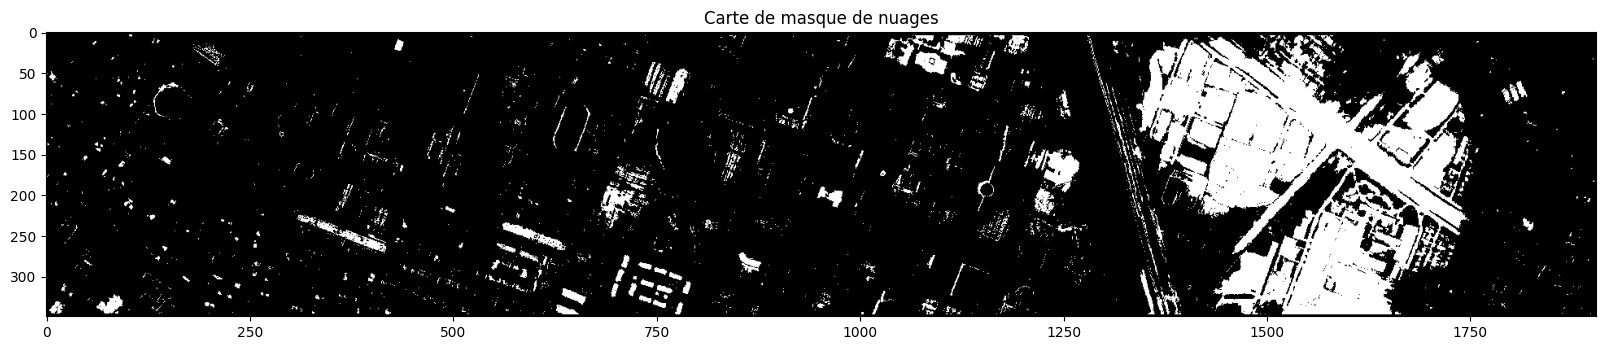

In [5]:
# Afficher le deuxième subplot en grand
fig, ax = plt.subplots(figsize=(20,8))
ax.imshow(cloud_mask, cmap='gray')
ax.set_title('Carte de masque de nuages')

plt.show()

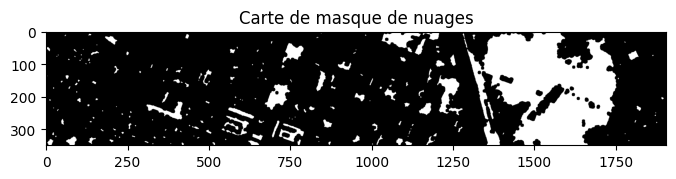

In [6]:
# Effectuer une fermeture et une ouverture sur la carte de masque de nuages
cloud_mask = morphology.binary_closing(cloud_mask,morphology.disk(5))
cloud_mask = morphology.binary_opening(cloud_mask)

# Visualisation des résultats
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(cloud_mask, cmap='gray')
ax.set_title('Carte de masque de nuages')

plt.show()

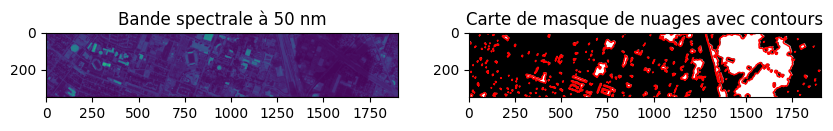

In [7]:
rgb_bands = [54,32,18]
hsi_rgb = hsi[:,:,rgb_bands]
hsi_rgb = hsi_rgb/hsi_rgb.max() # normalisation des valeurs dans [0,1] pour l'affichage

pmin,pmax = np.percentile(hsi_rgb,(1,95),axis=(0,1))
hsi_rgb_pimped = hsi_rgb.copy()
for i in range(pmin.size):
    hsi_rgb_pimped[:,:,i] = (hsi_rgb[:,:,i]-pmin[i])/(pmax[i]-pmin[i])
hsi_rgb_pimped[hsi_rgb_pimped<0] = 0
hsi_rgb_pimped[hsi_rgb_pimped>1] = 1

# Trouver les contours du nuage
contours = measure.find_contours(cloud_mask, 0.8)

# Visualisation des résultats
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(hsi[:, :, 54])
ax1.set_title('Bande spectrale à 50 nm')

ax2.imshow(cloud_mask, cmap='gray')
for contour in contours:
    ax2.plot(contour[:, 1], contour[:, 0], linewidth=1, color='r')
ax2.set_title('Carte de masque de nuages avec contours')

plt.show()

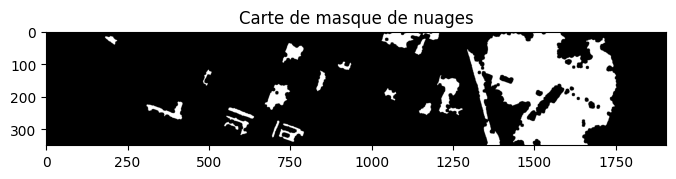

In [8]:
labels, num_labels = ndimage.label(cloud_mask)

# Trouver les coordonnées des régions connexes
regions = ndimage.find_objects(labels)

# Définir une taille minimale pour les régions connexes
min_size = 1000

# Parcourir les régions connexes et supprimer celles qui sont trop petites
for i in range(num_labels):
    region = regions[i]
    size = (region[0].stop - region[0].start) * (region[1].stop - region[1].start)
    if size < min_size:
        cloud_mask[region[0], region[1]] = 0

# Visualisation des résultats
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(cloud_mask, cmap='gray')
ax.set_title('Carte de masque de nuages')

plt.show()

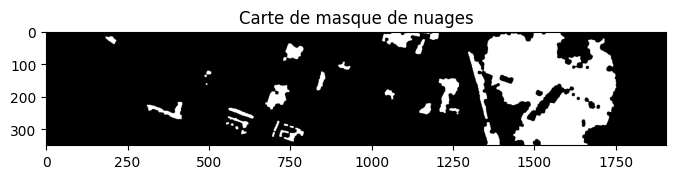

In [9]:
# Appliquer une ouverture morphologique pour supprimer les petites zones
cloud_mask = morphology.opening(cloud_mask, morphology.square(5))

# Visualisation des résultats
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(cloud_mask, cmap='gray')
ax.set_title('Carte de masque de nuages')

plt.show()

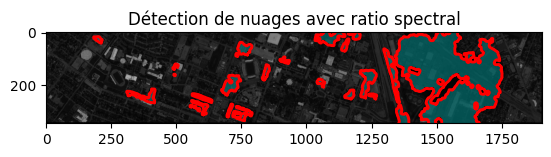

In [10]:
### Trouver les contours des nuages
contours = measure.find_contours(cloud_mask, 0.5)

# Superposer le masque de nuages et les contours sur l'image originale
plt.imshow(hsi[:, :, 54], cmap='gray')
plt.imshow(np.ma.masked_where(cloud_mask == 0, cloud_mask), cmap='cool', alpha=0.3)

for contour in contours:
    plt.plot(contour[:, 1], contour[:, 0], linewidth=2, color='red')

plt.title('Détection de nuages avec ratio spectral')
plt.show()###

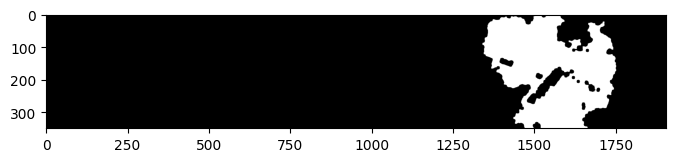

In [11]:
# Identifier les différentes régions connectées dans le masque de nuages
labelled_mask = measure.label(cloud_mask)

# Récupérer les propriétés de chaque région
props = measure.regionprops(labelled_mask)

# Trouver l'indice de la région la plus grande
max_area = 0
max_index = 0
for i, region in enumerate(props):
    if region.area > max_area:
        max_area = region.area
        max_index = i

# Créer un masque pour la région la plus grande
largest_region_mask = np.zeros_like(cloud_mask)
largest_region_mask[labelled_mask == max_index + 1] = 1

# Visualisation des résultats
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(largest_region_mask, cmap='gray')
#ax.title('Carte de masque de nuages avec la plus grande région')

plt.show()

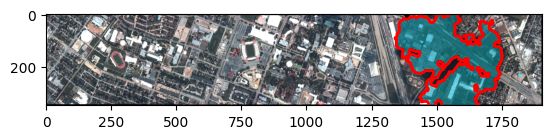

In [12]:
contours = measure.find_contours(largest_region_mask, 0.5)

# Superposer le masque de nuages et les contours sur l'image originale
plt.imshow(hsi_rgb_pimped, cmap='gray')
plt.imshow(np.ma.masked_where(largest_region_mask == 0, largest_region_mask), cmap='cool', alpha=0.3)

for contour in contours:
    plt.plot(contour[:, 1], contour[:, 0], linewidth=2, color='red')

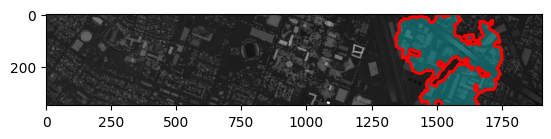

In [13]:
# Superposer le masque de nuages et les contours sur l'image originale
plt.imshow(lidar, cmap='gray')
plt.imshow(np.ma.masked_where(largest_region_mask == 0, largest_region_mask), cmap='cool', alpha=0.3)

for contour in contours:
    plt.plot(contour[:, 1], contour[:, 0], linewidth=2, color='red')

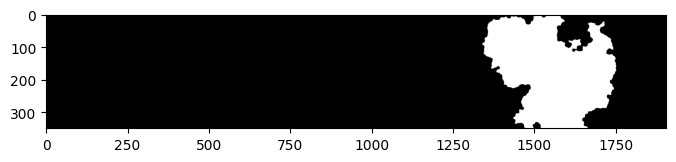

In [14]:
# Remplir les trous dans la région la plus grande
filled_mask = ndimage.binary_fill_holes(largest_region_mask)
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(filled_mask, cmap='gray')

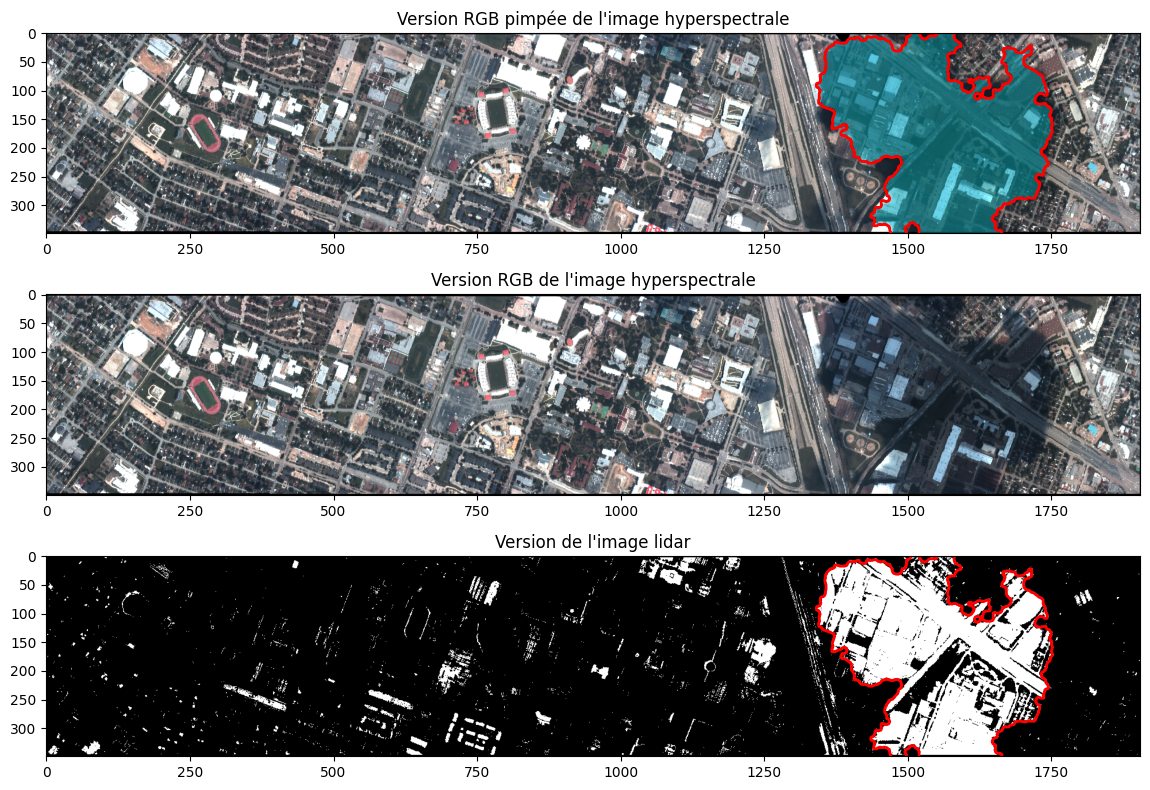

In [15]:
contours = measure.find_contours(filled_mask, 0.5)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(20, 8))

# Première ligne : image hyperspectrale avec masque
axes[0].imshow(hsi_rgb_pimped, cmap='gray')
axes[0].imshow(np.ma.masked_where(filled_mask == 0, filled_mask), cmap='cool', alpha=0.3)
for contour in contours:
    axes[0].plot(contour[:, 1], contour[:, 0], linewidth=2, color='red')
axes[0].set_title('Version RGB pimpée de l\'image hyperspectrale')

# Deuxième ligne : image hyperspectrale sans masque
axes[1].imshow(hsi_rgb_pimped)
axes[1].set_title('Version RGB de l\'image hyperspectrale')

# Troisième ligne : image lidar
axes[2].set_title('Version de l\'image lidar')
axes[2].imshow(cloud_mask_cp, cmap='gray')
#axes[2].imshow(np.ma.masked_where(filled_mask == 0, filled_mask), cmap='cool', alpha=0.3)
for contour in contours:
    axes[2].plot(contour[:, 1], contour[:, 0], linewidth=2, color='red')
plt.tight_layout()
plt.show()

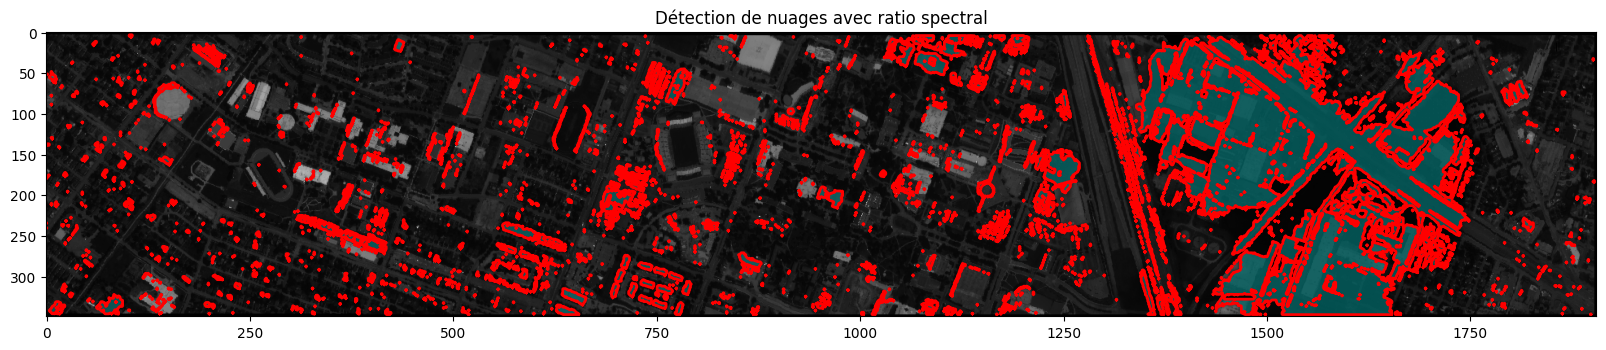

In [16]:
### Trouver les contours des nuages
contours = measure.find_contours(cloud_mask_cp, 0.5)

# Superposer le masque de nuages et les contours sur l'image originale
plt.figure(figsize=(20,8))
plt.imshow(hsi[:, :, 54], cmap='gray')
plt.imshow(np.ma.masked_where(cloud_mask_cp == 0, cloud_mask_cp), cmap='cool', alpha=0.3)

for contour in contours:
    plt.plot(contour[:, 1], contour[:, 0], linewidth=2, color='red')

plt.title('Détection de nuages avec ratio spectral')
plt.show()###

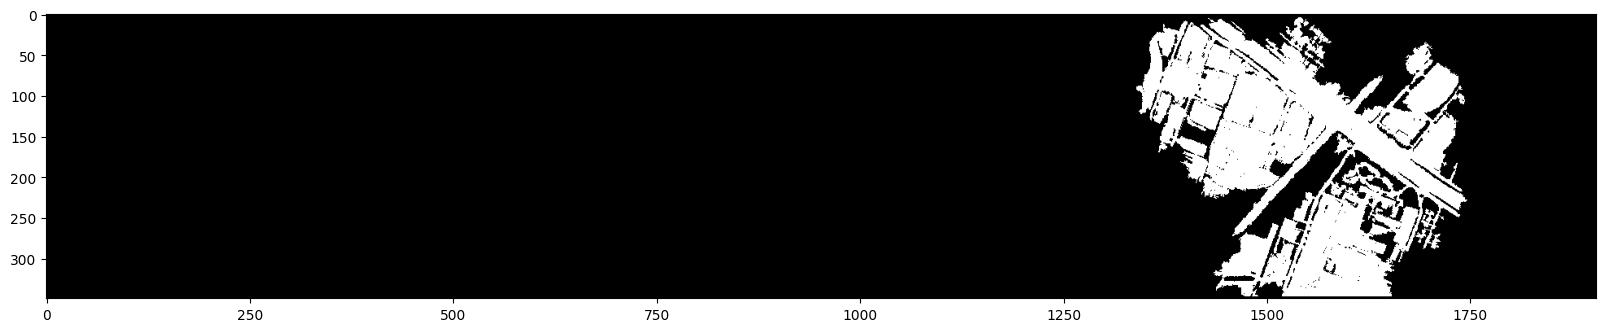

In [17]:
# Identifier les différentes régions connectées dans le masque de nuages
labelled_mask = measure.label(cloud_mask_cp)

# Récupérer les propriétés de chaque région
props = measure.regionprops(labelled_mask)

# Trouver l'indice de la région la plus grande
max_area = 0
max_index = 0
for i, region in enumerate(props):
    if region.area > max_area:
        max_area = region.area
        max_index = i

# Créer un masque pour la région la plus grande
largest_region_mask = np.zeros_like(cloud_mask)
largest_region_mask[labelled_mask == max_index + 1] = 1

# Visualisation des résultats
fig, ax = plt.subplots(figsize=(20,8))
ax.imshow(largest_region_mask, cmap='gray')
#ax.title('Carte de masque de nuages avec la plus grande région')

plt.show()

In [18]:
# Extraire la hauteur de chaque pixel dans l'image lidar
lidar_height = lidar.flatten()

# Initialiser une matrice pour stocker les caractéristiques extraites de l'image lidar
lidar_features = np.zeros((lidar_height.shape[0], 2))

# Extraire la densité de points pour chaque pixel dans l'image lidar
lidar_density = np.zeros_like(lidar_height)
lidar_density = np.sum(lidar > 0, axis=(0,1)) - 1
lidar_density = np.zeros(lidar.shape)

# Mettre à jour la matrice des caractéristiques avec la hauteur et la densité de points de chaque pixel
lidar_features[:,0] = lidar_height
lidar_features[:,1] = lidar_density.flatten()

In [19]:
height = lidar[:,:]
#point_density = lidar[:,:,1]

# Créer un array numpy avec les caractéristiques de chaque pixel
#lidar_features = np.column_stack((height.flatten(), point_density.flatten()))
print(height)
print("Lidar shape:", lidar.shape[0], lidar.shape[1])
print(lidar)

rows, cols = lidar.shape

# Initialiser une matrice pour stocker les caractéristiques extraites de l'image lidar
lidar_features = np.zeros((rows*cols, 2))

# Boucler sur chaque pixel de l'image lidar et extraire la hauteur et la densité de points
for i in range(rows):
    for j in range(cols):
        pixel_idx = i*cols + j
        pixel_height = lidar[i,j]
        pixel_density = np.sum(lidar[max(0,i-1):min(rows,i+1), max(0,j-1):min(cols,j+1)] > 0)
        lidar_features[pixel_idx, 0] = pixel_height
        lidar_features[pixel_idx, 1] = pixel_density


[[22.307486 22.246687 23.591436 ... 18.466406 14.067892 10.819799]
 [22.649158 23.642786 23.22117  ... 14.941597 10.672011 10.864208]
 [21.929605 22.688917 22.565989 ... 11.538835 11.306308 10.965059]
 ...
 [11.852781 12.890382 17.900314 ...  9.497825 12.765472  9.896922]
 [16.565516 18.417171 18.457718 ...  9.732936  9.496911  9.130429]
 [19.24429  20.728527 16.821402 ...  9.732739  9.813254  9.609959]]
Lidar shape: 349 1905
[[22.307486 22.246687 23.591436 ... 18.466406 14.067892 10.819799]
 [22.649158 23.642786 23.22117  ... 14.941597 10.672011 10.864208]
 [21.929605 22.688917 22.565989 ... 11.538835 11.306308 10.965059]
 ...
 [11.852781 12.890382 17.900314 ...  9.497825 12.765472  9.896922]
 [16.565516 18.417171 18.457718 ...  9.732936  9.496911  9.130429]
 [19.24429  20.728527 16.821402 ...  9.732739  9.813254  9.609959]]


In [20]:
# Extraire les valeurs de réflectance pour chaque bande spectrale
#refl_data = np.transpose(hsi_rgb_pimped, (2, 0, 1))
#num_bands = refl_data.shape[0]
print("Pimped shape:", hsi_rgb_pimped.shape[0], hsi_rgb_pimped.shape[1], hsi_rgb_pimped.shape[2])
refl_values = []
num_bands = hsi.shape[2]
for band in range(num_bands):
    band_data = hsi[:, :, band]
    refl_values.append(band_data)

#On isole chaque spectre et o recupere la bande
print("Shape raw:",hsi.shape[0],hsi.shape[1],hsi.shape[2])
len(refl_values)

Pimped shape: 349 1905 3
Shape raw: 349 1905 144


144